# **Medical LLM Fine-Tuning: QLoRA on Qwen3-4B-Instruct-2507**

### It fine-tunes Qwen/Qwen-4B-Instuct-2507 on GBanker/MedQA-USMLE-4-options-hf with QLORA: 4-bit NF4 with FP16 compute, LoRA r=16 / alpha=32 / dropout = 0.05, batch 4 x grad-accum, 3 epochs, LR 2e-4, 512 tokens, TensorBoard 

## **1. Install packages**

In [1]:
# Install required libraries and dependencies

!pip install -q -U "transformers>=4.56" "trl>=0.20" "peft>=0.14" "bitsandbytes>=0.45" datasets accelerate tensorboard scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 84.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 23.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 49.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depen

## **2. Setup and Configuration**

In [2]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
# Import required libraries

import gc, json, math, random, re, shutil, time, dataclasses 
from pathlib import Path

import numpy as np 
import torch 
import transformers, peft, trl, datasets 
from datasets import load_dataset 
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, set_seed
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTConfig, SFTTrainer
from sklearn.metrics import accuracy_score, f1_score

In [4]:
# Configuration

SMOKE_TEST = False

BASE_MODEL   = "Qwen/Qwen3-4B-Instruct-2507"
DATASET_NAME = "GBaker/MedQA-USMLE-4-options-hf"
SEED         = 42 
MAX_LEN      = 512
N_EVAL       = 500 if not SMOKE_TEST else 16 # fixed test slice for baseline and fine-tuned model
EVAL_BATCH   = 8 
N_VAL        = 200 # validation subset for eval-loss curves during training
EPOCHS, BATCH, GRAD_ACC, LR = 3, 4, 4, 2e-4

OUT = Path("/kaggle/working/outputs_smoke" if SMOKE_TEST else "kaggle/working/outputs")
ADAPTER_DIR = OUT / "adapter"
LOG_DIR = OUT / "logs" / "tensorboard"
CKPT_DIR = OUT / "checkpoints"
REPORT_DIR = OUT / "reports"

for d in (ADAPTER_DIR, LOG_DIR, CKPT_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

os.environ["TENSORBOARD_LOGGING_DIR"] = str(LOG_DIR)

set_seed(SEED)

## **3. Dataset**

In [6]:
# Load Dataset

raw = load_dataset(DATASET_NAME)
print(raw)
print("Columns: ", raw["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['id', 'sent1', 'sent2', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 10178
    })
    validation: Dataset({
        features: ['id', 'sent1', 'sent2', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 1272
    })
    test: Dataset({
        features: ['id', 'sent1', 'sent2', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 1273
    })
})
Columns:  ['id', 'sent1', 'sent2', 'ending0', 'ending1', 'ending2', 'ending3', 'label']


In [7]:
# Normalize dataset schemas and prepare train, validation and test splits

LETTERS = ["A", "B", "C", "D"]

def normalize(ex):
    if "ending0" in ex:
        q = (ex["sent1"] or "").strip()
        if ex.get("sent2"):
            q = f"{q} {ex['sent2'].strip()}".strip()
        opts = [ex[f"ending{i}"] for i in range(4)]
        ans = LETTERS[int(ex["label"])]
    elif "options" in ex:
        q = ex["question"].strip()
        o = ex["options"]
        opts = [o[l] for l in LETTERS] if isinstance(o, dict) else list(o)
        idx = ex["answer_idx"]
        ans = idx if isinstance(idx, str) else LETTERS[int(idx)]
    else:
        raise KeyError(f"Unknown schema, columns: {list(ex.keys())}")

    return {"question": q, "options": opts, "answer": ans}

def get_splits(*names):
    for n in names:
        if n in raw:
            return raw[n]
    return None

def norm(split):
    return split.map(normalize, remove_columns=split.column_names)

train_norm = norm(raw["train"])
test_norm = norm(get_splits("test"))
val_split = get_splits("validation", "dev")
val_norm = norm(val_split) if val_split is not None else None 

print({
        "train": len(train_norm), 
        "val": len(val_norm) if val_norm else None, 
        "test": len(test_norm)
})   

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

Map:   0%|          | 0/1273 [00:00<?, ? examples/s]

Map:   0%|          | 0/1272 [00:00<?, ? examples/s]

{'train': 10178, 'val': 1272, 'test': 1273}


In [8]:
# Quick Dataset check 

print(train_norm[0])

{'question': 'A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?', 'options': ['Ampicillin', 'Ceftriaxone', 'Doxycycline', 'Nitrofurantoin'], 'answer': 'D'}


In [9]:
# lets see the balance of answers in training set 

print("Train answer balance: ", {
         l: train_norm["answer"].count(l) for l in LETTERS})

Train answer balance:  {'A': 2584, 'B': 2654, 'C': 2557, 'D': 2383}


## **4. Prompt format and token-length check**

In [10]:
# Tokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Explicitly use right padding for causal LM training.
tokenizer.padding_side = "right"

print("pad: ", tokenizer.pad_token, "| eos:", tokenizer.eos_token)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

pad:  <|endoftext|> | eos: <|im_end|>


In [11]:
# Prompt Format

SYSTEM_PROMPT = (
    "You are a medical expert answering USMLE-style multiple-choice questions. "
    "Select single best answer. Reply with the answer letter and the option text only, "
    "in the format 'C) <option text>'."
)

def user_message(question, options):
    opts = "\n".join(f"{l}) {t}" for l, t in zip(LETTERS, options))
    return f"Question:\n{question}\n\nOptions:\n{opts}"

def prompt_messages(ex):
    return[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_message(ex["question"], ex["options"])}
    ]

def gold_completion(ex):
    answer = ex["answer"]

    option_text = ex["options"][
    LETTERS.index(answer)
    ]
    
    return f"{answer}) {option_text}"

def to_sft(ex):
    return {
        "prompt": prompt_messages(ex),
        "completion": [{"role": "assistant", "content": gold_completion(ex)}]
    }

In [12]:
# Token length check

def n_tokens(ex):
    messages = (
        prompt_messages(ex)
        + [
            {
                "role": "assistant",
                "content": gold_completion(ex),
            }
        ]
    )

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    
    token_ids = tokenizer(
    text,
    add_special_tokens=False,
    )["input_ids"]

    return {
        "n_tokens": len(token_ids)
    }

train_len = train_norm.map(n_tokens)
lens = np.array(train_len["n_tokens"])

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

In [13]:
# Analyze token length distribution and check sequence truncation

print(
    "Token length percentiles p50/p90/p95/p99/max:",
    [int(np.percentile(lens, p)) for p in (50, 90, 95, 99)],
    int(lens.max())
)

# Check for tokens that are greater than MAX_LEN
print(
    f"Examples longer than {MAX_LEN} tokens: "
    f"{(lens > MAX_LEN).sum()} "
    f"({(lens > MAX_LEN).mean():.1%})"
)

Token length percentiles p50/p90/p95/p99/max: [261, 378, 422, 526] 1003
Examples longer than 512 tokens: 122 (1.2%)


In [14]:
# prepare data for training
# Remove examples that are too long 

train_fit = train_len.filter(lambda e: e["n_tokens"] <= MAX_LEN)

if SMOKE_TEST:
    train_fit = train_fit.shuffle(seed=SEED).select(range(min(256, len(train_fit))))
train_sft = train_fit.map(to_sft, remove_columns=train_fit.column_names)

val_sft = None 
if val_norm is not None and not SMOKE_TEST:
    val_sft = val_norm.shuffle(seed=SEED).select(range(min(N_VAL, len(val_norm)))).map(
        to_sft, remove_columns=val_norm.column_names
    )

Filter:   0%|          | 0/10178 [00:00<?, ? examples/s]

Map:   0%|          | 0/10056 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [15]:
# Display the number of training and validation examples

print(f"Training examples: {len(train_sft)} | validation examples: {len(val_sft) if val_sft else 0}")

Training examples: 10056 | validation examples: 200


In [16]:
# Preview the formatted prompt

print("What model sees: ")
print(tokenizer.apply_chat_template(train_sft[0]["prompt"] + train_sft[0]["completion"], 
                                    tokenizer=False))

What model sees: 
{'input_ids': [151644, 8948, 198, 2610, 525, 264, 6457, 6203, 35764, 2274, 25045, 11297, 5248, 62626, 4755, 13, 8427, 3175, 1850, 4226, 13, 17841, 448, 279, 4226, 6524, 323, 279, 2999, 1467, 1172, 11, 304, 279, 3561, 364, 34, 8, 366, 2047, 1467, 44689, 151645, 198, 151644, 872, 198, 14582, 510, 32, 220, 17, 18, 4666, 6284, 20280, 5220, 518, 220, 17, 17, 5555, 12743, 367, 18404, 448, 19675, 5193, 4335, 2554, 13, 2932, 5302, 432, 3855, 220, 16, 1899, 4134, 323, 702, 1012, 92305, 8818, 16163, 803, 3015, 323, 4633, 69537, 15357, 8649, 13, 2932, 5937, 11074, 1632, 323, 374, 8110, 553, 264, 10668, 369, 1059, 19636, 13, 6252, 9315, 374, 220, 24, 22, 13, 22, 58472, 320, 18, 21, 13, 20, 30937, 701, 6543, 7262, 374, 220, 16, 17, 17, 14, 22, 22, 9465, 39, 70, 11, 27235, 374, 220, 23, 15, 44173, 11, 32415, 804, 525, 220, 16, 24, 44173, 11, 323, 23552, 49743, 374, 220, 24, 23, 4, 389, 3054, 3720, 13, 27379, 7006, 374, 27190, 369, 458, 19265, 315, 2783, 1975, 665, 41643, 9210, 8376

## **5. Load the model in 4-bit (NF4 + double quantisation + FP16 compute)**

In [17]:
# Load the base model with 4-bit quantization

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=torch.float16,
    attn_implementation="sdpa",
)

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

In [18]:
# Check GPU memory usage after loading the model

print(f"Loaded. GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB | reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

Loaded. GPU memory allocated: 2.49 GB | reserved: 2.53 GB


## **6. Evaluation helpers and a fixed test slice**

In [20]:
# Create the evaluation subset

eval_idx = random.Random(SEED).sample(range(len(test_norm)), N_EVAL)
eval_set = [test_norm[i] for i in eval_idx]
(REPORT_DIR / "eval_indices.json").write_text(json.dumps(eval_idx))
print("Eval slice:", len(eval_set), "questions | answer balance:", {l: sum(e["answer"] == l for e in eval_set) for l in LETTERS})

Eval slice: 500 questions | answer balance: {'A': 142, 'B': 122, 'C': 131, 'D': 105}


In [21]:
# Parse and validate model answers

LEAD = r"^[\s\(\*\[]*"   # optional leading space, '(', '*', '['
def parse_choice(text):
    m = re.match(LEAD + r"([ABCD])(?=[\)\]\.:\*]|\s*$)", text.strip())
    if m:
        return m.group(1)
    m = re.search(r"answer\s*(?:is|:)?\s*[\(\*\[]*([ABCD])\b", text, flags=re.I)
    return m.group(1).upper() if m else None

def option_text_ok(text, letter, options):
    body = re.sub(LEAD + r"[ABCD][\)\]\.:\*]*\s*", "", text.strip(), count=1).strip().lower()
    if not body:
        return True   # letter only -> nothing to contradict
    gold = options[LETTERS.index(letter)].strip().lower()
    return gold in body or body in gold  # body in gold tolerates truncated generations

In [22]:
# Evaluate the model

@torch.no_grad()
def evaluate_model(model, tokenizer, examples, tag, max_new_tokens=64, batch_size=EVAL_BATCH):
    model.eval()
    prev_side, tokenizer.padding_side = tokenizer.padding_side, "left"     # left-pad for generation
    prompts = [tokenizer.apply_chat_template(prompt_messages(e), tokenize=False, add_generation_prompt=True) for e in examples]
    t0, rows = time.time(), []
    for i in range(0, len(prompts), batch_size):
        enc = tokenizer(prompts[i:i + batch_size], return_tensors="pt", padding=True, add_special_tokens=False).to("cuda")
        out = model.generate(
            **enc, max_new_tokens=max_new_tokens, do_sample=False,       # greedy = reproducible
            temperature=None, top_p=None, top_k=None,
            use_cache=True, pad_token_id=tokenizer.pad_token_id,
        )
        texts = tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
        for j, text in enumerate(texts):
            ex = examples[i + j]
            pred = parse_choice(text)
            rows.append({
                "gold": ex["answer"], "pred": pred, "output": text,
                "invalid": pred is None,
                "mismatch": pred is not None and not option_text_ok(text, pred, ex["options"]),
            })
    tokenizer.padding_side = prev_side

    y_true = [r["gold"] for r in rows]
    y_pred = [r["pred"] or "INVALID" for r in rows]
    per_class = f1_score(y_true, y_pred, labels=LETTERS, average=None, zero_division=0)
    n = len(rows)
    metrics = {
        "tag": tag, "n": n,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=LETTERS, average="macro", zero_division=0),
        "per_class_f1": {l: float(v) for l, v in zip(LETTERS, per_class)},
        "invalid_rate": sum(r["invalid"] for r in rows) / n,
        "mismatch_rate": sum(r["mismatch"] for r in rows) / n,
        "seconds": round(time.time() - t0, 1),
    }
    metrics["hallucination_rate"] = metrics["invalid_rate"] + metrics["mismatch_rate"]
    (REPORT_DIR / f"{tag}.json").write_text(json.dumps({"metrics": metrics, "predictions": rows}, indent=2))
    return metrics

In [23]:
# Display evaluation results

def show(m):
    print(f"[{m['tag']}] n={m['n']}  acc={m['accuracy']:.3f}  macroF1={m['macro_f1']:.3f}  "
          f"invalid={m['invalid_rate']:.3f}  mismatch={m['mismatch_rate']:.3f}  ({m['seconds']}s)")
    print("   per-class F1:", {k: round(v, 3) for k, v in m["per_class_f1"].items()})

## **7. Baseline (base model, before any training)**


In [24]:
# Evaluate the baseline model and inspect sample predictions

baseline = evaluate_model(model, tokenizer, eval_set, "baseline")
show(baseline)
print("\nSample raw outputs:")
for r in json.loads((REPORT_DIR / "baseline.json").read_text())["predictions"][:3]:
    print(f"  gold={r['gold']} pred={r['pred']} | {r['output'][:120]!r}")

[baseline] n=500  acc=0.490  macroF1=0.487  invalid=0.000  mismatch=0.020  (399.6s)
   per-class F1: {'A': 0.408, 'B': 0.535, 'C': 0.5, 'D': 0.505}

Sample raw outputs:
  gold=A pred=A | 'A) Chikungunya\n\nRationale: The patient presents with fever, joint pain (especially in hands and wrists), a maculopapular'
  gold=A pred=D | 'D) Impaired kidney perfusion'
  gold=A pred=C | 'C) Botryoid sarcoma'


## **8. Prepare for QLoRA and attach the LoRA adapter**

In [24]:
# Prepare the model for QLoRA fine-tuning and configure LoRA adapters

model = prepare_model_for_kbit_training(
    model, use_gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False}
)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none", task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
for p in model.parameters():
    if p.requires_grad:
        p.data = p.data.float()
model.print_trainable_parameters() # expect roughly 33M trainable (~0.9%)

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


## **9. Training configuration and trainer**

In [25]:
# Configure training arguments and initialize the SFT trainer

steps_per_epoch = math.ceil(len(train_sft) / (BATCH * GRAD_ACC))
total_steps     = 15 if SMOKE_TEST else steps_per_epoch * EPOCHS
warmup_steps    = max(1, int(0.03 * total_steps))
print(f"steps/epoch={steps_per_epoch} | total optimizer steps={total_steps} | warmup={warmup_steps}")

cfg = dict(
    output_dir=str(CKPT_DIR),
    num_train_epochs=EPOCHS,
    max_steps=total_steps if SMOKE_TEST else -1,
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACC,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    optim="paged_adamw_8bit",
    fp16=True, bf16=False,
    max_length=MAX_LEN,
    packing=False,
    completion_only_loss=True, # loss on the answer only, not the question
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=10,
    save_strategy="steps", save_steps=250, save_total_limit=2,
    report_to=["tensorboard"],
    seed=SEED,
)
if val_sft is not None:
    cfg.update(eval_strategy="steps", eval_steps=250, per_device_eval_batch_size=BATCH)
if "logging_dir" in {f.name for f in dataclasses.fields(SFTConfig)}:
    cfg["logging_dir"] = str(LOG_DIR)

training_args = SFTConfig(**cfg)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_sft,
    eval_dataset=val_sft,
    processing_class=tokenizer,
)

steps/epoch=629 | total optimizer steps=1887 | warmup=56


Tokenizing train dataset:   0%|          | 0/10056 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/10056 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10056 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/10056 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

## Sanity check before the expensive cell

In [ ]:
# Verify the training batch

batch = next(iter(trainer.get_train_dataloader()))
print("batch keys:", list(batch.keys()))
if "labels" in batch:
    labels = batch["labels"][0]
    sup = labels[labels != -100]
    print(f"supervised tokens: {len(sup)} of {int((batch['attention_mask'][0] == 1).sum())}")
    print("decoded supervised text:", repr(tokenizer.decode(sup)))
else:
    print("No 'labels' key in this TRL version; check completion_mask instead:", "completion_mask" in batch)
del batch

## **10. Train**

In [ ]:
# Add an FP32 callback
from transformers import TrainerCallback

class CastTrainableToFP32(TrainerCallback):
    def on_train_begin(self, args, state, control, model=None, **kwargs):
        n = 0
        for p in model.parameters():
            if p.requires_grad and p.dtype != torch.float32:
                p.data = p.data.float()
                n += 1
        print(f"Cast {n} trainable tensors to fp32")

trainer.add_callback(CastTrainableToFP32())

In [ ]:
# Start or resume model training

RESUME = True      # continue from the latest checkpoint if the session was interrupted
ckpts = sorted(CKPT_DIR.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))
resume_from = str(ckpts[-1]) if (RESUME and ckpts) else None
print("Resuming from:", resume_from)

train_result = trainer.train(resume_from_checkpoint=resume_from)

## **11. Save the adapter, metrics and logs**

In [27]:
# Save the trained LoRA adapter, tokenizer, metrics

trainer.save_model(str(ADAPTER_DIR))              # LoRA adapter only
tokenizer.save_pretrained(str(ADAPTER_DIR))

(OUT / "training_metrics.json").write_text(json.dumps(train_result.metrics, indent=2))
(OUT / "log_history.json").write_text(json.dumps(trainer.state.log_history, indent=2))
(OUT / "run_config.json").write_text(json.dumps({
    "base_model": BASE_MODEL, "dataset": DATASET_NAME, "smoke_test": SMOKE_TEST, "seed": SEED,
    "max_len": MAX_LEN, "train_examples": len(train_sft), "epochs": EPOCHS, "batch": BATCH,
    "grad_acc": GRAD_ACC, "lr": LR, "lora": lora_config.to_dict() if hasattr(lora_config, "to_dict") else str(lora_config),
    "versions": {m.__name__: m.__version__ for m in (torch, transformers, peft, trl)},
}, indent=2, default=str))

print(json.dumps(train_result.metrics, indent=2))
for p in sorted(ADAPTER_DIR.iterdir()):
    print(f"{p.stat().st_size/1024**2:8.1f} MB  {p.name}")

In [25]:
print(type(model))

<class 'transformers.models.qwen3.modeling_qwen3.Qwen3ForCausalLM'>


In [26]:
# Load the best checkpoint (step 500) onto the base model

CKPT_PATH = Path("/kaggle/input/datasets/nikeshbhattarai1/mycheckpoint")

model = PeftModel.from_pretrained(model, CKPT_PATH)
model.eval()
model.config.use_cache = True

## **12. Evaluate the fine-tuned model on the same slice and write comparison.json**

In [27]:
# Evaluate the fine-tuned model and compare it with the baseline

model.config.use_cache = True
finetuned = evaluate_model(model, tokenizer, eval_set, "finetuned")
show(baseline); show(finetuned)

comparison = {
    "smoke_test": SMOKE_TEST,
    "n_questions": N_EVAL,
    "eval_indices_file": "eval_indices.json",
    "baseline": baseline,
    "finetuned": finetuned,
    "delta": {k: finetuned[k] - baseline[k] for k in ("accuracy", "macro_f1", "invalid_rate", "mismatch_rate", "hallucination_rate")},
}
(REPORT_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))

print(f"\n{'metric':20s}{'baseline':>10s}{'finetuned':>11s}{'delta':>9s}")
for k in ("accuracy", "macro_f1", "invalid_rate", "mismatch_rate", "hallucination_rate"):
    print(f"{k:20s}{baseline[k]:10.3f}{finetuned[k]:11.3f}{comparison['delta'][k]:+9.3f}")
if N_EVAL < 200:
    print(f"\nNote: with n={N_EVAL}, one question = {100/N_EVAL:.1f} accuracy points. Treat small deltas as noise.")

[baseline] n=500  acc=0.490  macroF1=0.487  invalid=0.000  mismatch=0.020  (399.6s)
   per-class F1: {'A': 0.408, 'B': 0.535, 'C': 0.5, 'D': 0.505}
[finetuned] n=500  acc=0.614  macroF1=0.614  invalid=0.000  mismatch=0.002  (297.8s)
   per-class F1: {'A': 0.596, 'B': 0.648, 'C': 0.63, 'D': 0.58}

metric                baseline  finetuned    delta
accuracy                 0.490      0.614   +0.124
macro_f1                 0.487      0.614   +0.126
invalid_rate             0.000      0.000   +0.000
mismatch_rate            0.020      0.002   -0.018
hallucination_rate       0.020      0.002   -0.018


## **13. Training and Validation Loss Curve**

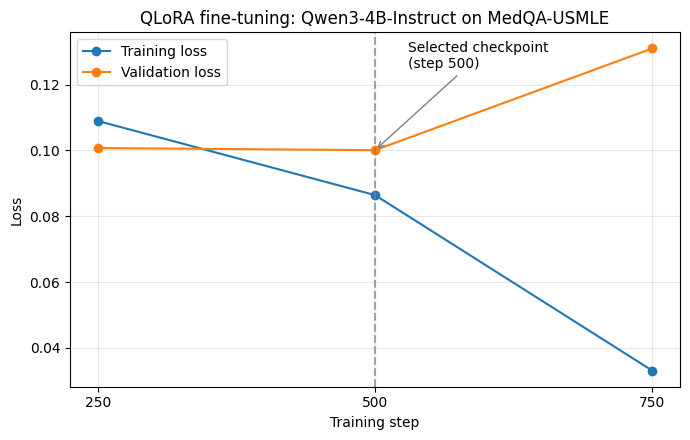

In [29]:
# Plot training vs validation loss and mark the selected checkpoint

import matplotlib.pyplot as plt

steps      = [250, 500, 750]
train_loss = [0.108980, 0.086443, 0.033089]
val_loss   = [0.100748, 0.100093, 0.131019]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(steps, train_loss, marker="o", label="Training loss")
ax.plot(steps, val_loss, marker="o", label="Validation loss")

# Mark the selected checkpoint (lowest validation loss)
ax.axvline(500, linestyle="--", color="gray", alpha=0.7)
ax.annotate("Selected checkpoint\n(step 500)", xy=(500, 0.1001), xytext=(530, 0.125),
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title("QLoRA fine-tuning: Qwen3-4B-Instruct on MedQA-USMLE")
ax.set_xticks(steps)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig("/kaggle/working/loss_curve.png", dpi=200)
plt.show()

## **14. Save the best adapter (step 500)**

In [32]:
# Copy the best adapter (step 500) into the adapter folder for packaging

CKPT_PATH = Path("/kaggle/input/datasets/nikeshbhattarai1/mycheckpoint")

for f in ["adapter_model.safetensors", "adapter_config.json"]:
    shutil.copy(CKPT_PATH / f, ADAPTER_DIR / f)
tokenizer.save_pretrained(str(ADAPTER_DIR))

('kaggle/working/outputs/adapter/tokenizer_config.json',
 'kaggle/working/outputs/adapter/chat_template.jinja',
 'kaggle/working/outputs/adapter/tokenizer.json')

## **14. TensorBoard and packaging**

In [35]:
# Launch TensorBoard to monitor training metrics

%load_ext tensorboard
%tensorboard --logdir /kaggle/working/outputs/logs/tensorboard

In [36]:
# Package the adapter and reports into zip files for download

zip_path = shutil.make_archive(str(OUT.parent / f"{OUT.name}_adapter_and_reports"), "zip", root_dir=OUT, base_dir="adapter")
shutil.make_archive(str(OUT.parent / f"{OUT.name}_reports"), "zip", root_dir=OUT, base_dir="reports")
print("Created:", zip_path)
print("\nFiles:")
for p in sorted(OUT.rglob("*")):
    if p.is_file() and "checkpoints" not in p.parts:
        print(f"{p.stat().st_size/1024:10.1f} KB  {p.relative_to(OUT)}")

Created: /kaggle/working/kaggle/working/outputs_adapter_and_reports.zip

Files:
       1.2 KB  adapter/adapter_config.json
  129089.7 KB  adapter/adapter_model.safetensors
       2.6 KB  adapter/chat_template.jinja
   11155.1 KB  adapter/tokenizer.json
       0.7 KB  adapter/tokenizer_config.json
      90.3 KB  reports/baseline.json
       1.0 KB  reports/comparison.json
       2.5 KB  reports/eval_indices.json
      73.8 KB  reports/finetuned.json
